In [2]:

from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from xgboost import XGBRegressor

simplefilter("ignore")

In [10]:
# Set Matplotlib defaults
sns.set_style('whitegrid')
plt.rc(
    "figure",
    autolayout=True,
    figsize=(11, 4),
    titlesize=18,
    titleweight='bold',
)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)

data_dir = Path("../../Time Series/store-sales-time-series-forecasting")
industries = ["BuildingMaterials", "FoodAndBeverage"]
retail = pd.read_csv(
    data_dir / "us-retail-sales.csv",
    usecols=['Month'] + industries,
    parse_dates=['Month'],
    index_col='Month',
).to_period('D').reindex(columns=industries)
retail = pd.concat({'Sales': retail}, names=[None, 'Industries'], axis=1)

retail.head()

Sales                
Industries BuildingMaterials FoodAndBeverage
Month                                       
1992-01-01              8964           29589
1992-02-01              9023           28570
1992-03-01             10608           29682
1992-04-01             11630           30228
1992-05-01             12327           31677

We will use alinear regression first tolearn the trend in each series. Use a quadrtic order 2 for the trend.

In [11]:
y = retail.copy()

# Create trend features
dp = DeterministicProcess(
    index=y.index,   # dates from the training data
    constant=True,   # the intercept
    order=2,         # quadratic trend
    drop=True,       # drop terms to avoid collinearity
)

X = dp.in_sample()   # features for training data

idx_train, idx_test = train_test_split(y.index, test_size=12*4, shuffle=False)
X_train, X_test = X.loc[idx_train, :], X.loc[idx_test, :]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

# Make predictions
y_fit = pd.DataFrame(model.predict(X_train), index=y_train.index, columns=y_train.columns)
y_pred = pd.DataFrame(model.predict(X_test), index=y_test.index, columns=y_test.columns)

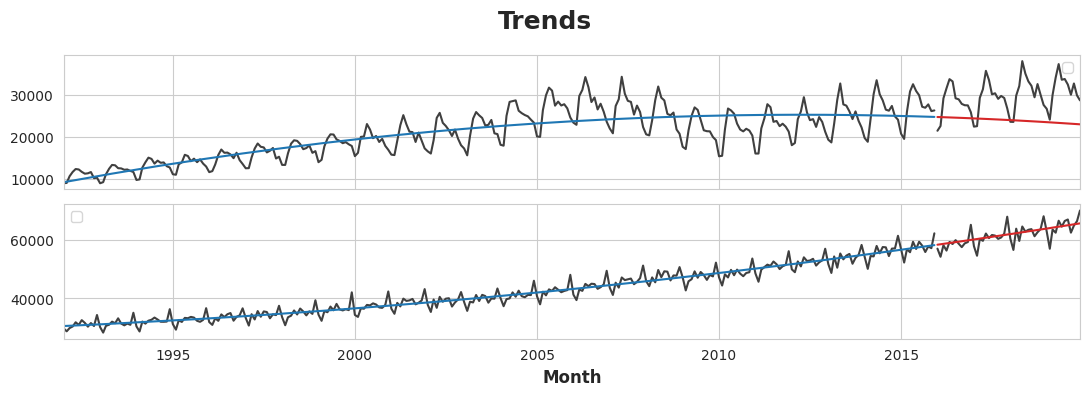

In [12]:
# Plots
axs = y_train.plot(color='0.25', subplots=True, sharex=True)
axs = y_test.plot(color='0.25', subplots=True, sharex=True, ax=axs)
axs = y_fit.plot(color='C0', subplots=True, sharex=True, ax=axs)
axs = y_pred.plot(color='C3', subplots=True, sharex=True, ax=axs)

for ax in axs:
    ax.legend([])
_ = plt.suptitle("Trends")

In [13]:
# The 'stack()' method converts column labels to row labels, pivoting from wide format to long
X = retail.stack()    # pivot dataset wide to long
display(X.head())
y = X.pop('Sales')    # grab the target series

Sales
Month      Industries              
1992-01-01 BuildingMaterials   8964
           FoodAndBeverage    29589
1992-02-01 BuildingMaterials   9023
           FoodAndBeverage    28570
1992-03-01 BuildingMaterials  10608

So that XGBoost can learn to distinguish our two time series, we'll turn the row labels for `'Industries'` into a categorical feature with a label encoding. We'll also create a feature for annual seasonality by pulling the month numbers out of the time index.

In [14]:
# Turn row labels into categorical feature columns with a label encoding
X = X.reset_index('Industries')
# Label encoding for 'Industries' feature
for colname in X.select_dtypes(["object", "category"]):
    X[colname], _ = X[colname].factorize()

# Label encoding for annual seasonality
X["Month"] = X.index.month    # values are 1, 2, ..., 12

X_train, X_test = X.loc[idx_train, :], X.loc[idx_test, :]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

Now we'll convert the trend predictions made earlier to long format and then subtract them from the original series. That will give us detrended (residual) series that XGBoost can learn.

In [15]:
# Pivot wide to long (stack) and convert DataFrame to Series (squeeze)
y_fit = y_fit.stack().squeeze()     # trend from training set
y_pred = y_pred.stack().squeeze()   # trend from text set

# Create residuals (the collection of detrended series) from the training set
y_resid = y_train - y_fit

# Train XGBoost on the residuals
xgb = XGBRegressor()
xgb.fit(X_train, y_resid)

# Add the predicted residuals onto the predicted trends
y_fit_boosted = xgb.predict(X_train) + y_fit
y_pred_boosted = xgb.predict(X_test) + y_pred

In [16]:
y_test

Month       Industries       
2016-01-01  BuildingMaterials    21408
            FoodAndBeverage      56931
2016-02-01  BuildingMaterials    22538
            FoodAndBeverage      54145
2016-03-01  BuildingMaterials    29101
                                 ...  
2019-10-01  FoodAndBeverage      64849
2019-11-01  BuildingMaterials    29793
            FoodAndBeverage      66363
2019-12-01  BuildingMaterials    28621
            FoodAndBeverage      70028
Name: Sales, Length: 96, dtype: int64

The fit appears quite good, though we can see how the trend learned by XGBoost is only as good as the trend learned by the linear regression -- in particular, XGBoost wasn't able to compensate for the poorly fit trend in the `'BuildingMaterials'` series.

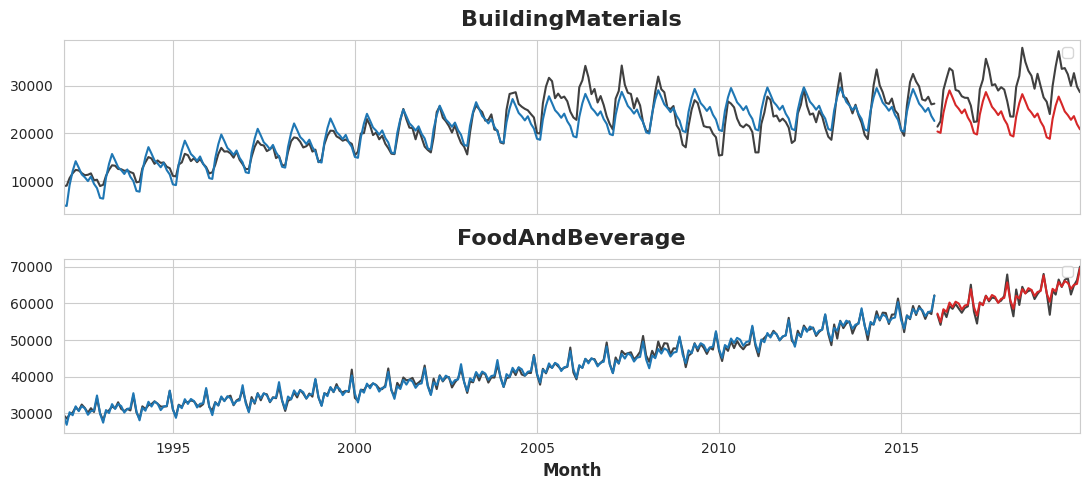

In [19]:
axs = y_train.unstack(['Industries']).plot(
    color='0.25', figsize=(11, 5), subplots=True, sharex=True, title=['BuildingMaterials','FoodAndBeverage'],
)
axs = y_test.unstack(['Industries']).plot(color='0.25', subplots=True, sharex=True, ax=axs)
axs = y_fit_boosted.unstack(['Industries']).plot(color='C0', subplots=True, sharex=True, ax=axs)
axs = y_pred_boosted.unstack(['Industries']).plot(color='C3', subplots=True, sharex=True, ax=axs)
for ax in axs:
    ax.legend([])